In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Alzheimer's Disease
- Alzheimer's disease is a progressive neurodegenrative disorder. It effects brain,causes decline in memory and cognitive power. It is a leading cause of dementia but all cases of dementia are not caused by alzheimer's disease.

- Alzheimer's disease cannot be cured but can be treated. It is difficult to detect the disease in it's early stages. The fact that it cannot be cured completely and it's early diagnosis is difficult, the specialists can only slow the progress of the disease with treatments after diagnosing it. 

- The main aim of this project is to show the true power of AI in health sector. How AI can benefit the health sector in diagnosis of diseases such as alzheimer. How AI can read brain patterns which human naked eye cannot read and are difficult to read for human eye. It is just a glimse of application of AI in health sector and how the field of health care will be revolutinized by AI in future.

- In this project we used an open source dataset from kaggle, which is a community of data scientist's, the dataset we used contains already preprocessed MRI images of alzheimer's disease for it's four stages which are explained following:
- Non Demented: MRI images of people who do not show any signs or symptoms for dementia.
- Very Mild Demented: MRI images of people with early signs of cognitive decline that are noticeable but mild in nature.
- Mild Demented: MRI images of people with more evident cognitive decline.
- Moderate Demented: MRI images of individuals exhibiting significant cognitive impairment.



# Project Overview:

### Data Collection:
- The dataset for this project is taken from kaggle,[dataset_link](https://www.kaggle.com/datasets/sachinkumar413/alzheimer-mri-dataset). Kaggle is a data scientist community where data scientist from all over the globe publish their datasets, notebooks and solutions of problems. It is an open source community and contains the largest database for open source datasets from different data domains.

### Data Preprocessing:
- Data preprocessing is the starting point of any data science project. In data preprocessing we load the data from different formats and made it available in the jupyter notebook for manipulation. In this phase formatting, cleaning and organization of data takes place. We have used os library to read images path from the data folders and than further processed the images path using pandas and finally loaded the images into numpy array using the numpy library.

### Exploratory Data Analysis:
- In this phase of project, we explore different variables of data. As the data we are working on are images so we can visualize the frequency distribution of each class and their respective MRI images. We have used seaborn and matplotlib for the exploratory data analysis.

### Data Preparation For Model Development:
- In this phase of the project, data is prepared to be fed into the mode. Preprocessing techniques like normalization are performed to achieve better results. Data splitting also takes place in this phase where we divide or split data into training, testing and validation sets.

### Model Development
- **Transfer Learning**: For model development we first experimented with the VGG16 model which is quite famous among the computer vision aspirants. VGG16 model is the winner of the imagenet competition took place in 2014 and it appears to work fine for image classification task. We will not train the weights of the layers of VGG16 instead we will use the already tuned model.

- **New Architecture**: After experiementing with the VGG16 model, we will build a new architecture and we will see how it performs. Does it perform better or worse?

### Model Evaluation Metrics:
- Usually model performance is evaluated using accuray score, but I will evaluate the model performance on three different metrics which are accuracy score, confusion matrix and classification report as the classification problem we are dealing has imablanced distribution.



### Model Selection:
- In this phase, the model with the best performance is selected. We will compare the performance of VGG16 and new architecture that we will make during the project and select the model that performs better than the other.


### Let's Get Started!

In [1]:
# importing the libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Dropout, Conv2D, Flatten, MaxPooling2D,BatchNormalization, AveragePooling2D
import os
import numpy as np
import cv2
import zipfile
import shutil
import random
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from pathlib import Path
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import save_model,load_model
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn import metrics
import logging
import warnings
warnings.filterwarnings("ignore")

# suppressing cuda warnings
tf.get_logger().setLevel(logging.ERROR)

2024-06-23 20:04:14.444253: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-23 20:04:14.444378: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-23 20:04:14.568657: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Data Collection 

In [2]:
# downloading the dataset directly from kaggle
!kaggle datasets download -d sachinkumar413/alzheimer-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/sachinkumar413/alzheimer-mri-dataset
License(s): copyright-authors
 18%|██████▊                               | 5.00M/28.0M [00:00<00:00, 37.4MB/s]
100%|███████████████████████████████████████| 28.0M/28.0M [00:00<00:00, 144MB/s]


In [3]:
# unzipping the file
zip = zipfile.ZipFile("/kaggle/working/alzheimer-mri-dataset.zip")

# extracting the zip file
zip.extractall("/kaggle/working")

# closing the zip file after extracting it
zip.close()

In [4]:
def loading_image_path(dir_path):
    
    # defining an empty list to store image path
    image_path = []

    # defining an empty list to store labels for image
    image_labels = []

    # applying a for loop to iterate on each image class folder
    for directory in os.listdir(dir_path):
        # listing the images in a image class directory
        images = os.listdir(os.path.join(dir_path,directory))

        # iterating on the images present in each directory
        for img in images:

            # appending the image path of the image in the list
            image_path.append(os.path.join(dir_path,directory,img))

            # appending the image label in the list
            image_labels.append(directory)
    return image_path, image_labels


In [5]:
# saving the directory path containing images
dir_path = "/kaggle/working/Dataset"
image_path, image_labels = loading_image_path(dir_path)

In [6]:
# making a dataframe containing two columns, one contaiing the image path and the other the label
df = pd.DataFrame({"image_path":image_path,"label":image_labels})

In [7]:
# checking the dataframe
df.head()

,image_path,label
0,/kaggle/working/Dataset/Very_Mild_Demented/ver...,Very_Mild_Demented
1,/kaggle/working/Dataset/Very_Mild_Demented/ver...,Very_Mild_Demented
2,/kaggle/working/Dataset/Very_Mild_Demented/ver...,Very_Mild_Demented
3,/kaggle/working/Dataset/Very_Mild_Demented/ver...,Very_Mild_Demented
4,/kaggle/working/Dataset/Very_Mild_Demented/ver...,Very_Mild_Demented


# Exploratory Data Analysis

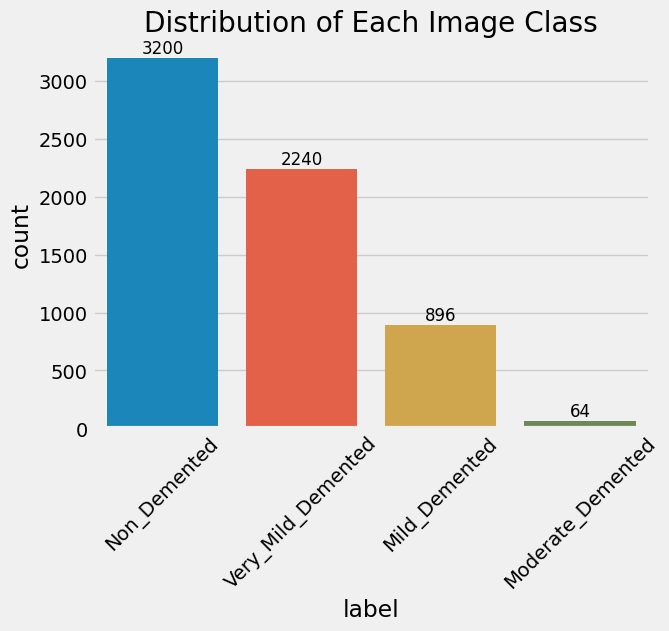

In [8]:
# Using five thirty eight style for the plot
plt.style.use("fivethirtyeight")

# setting class order to show bars from higher to lower frequency of images
class_order = ["Non_Demented","Very_Mild_Demented","Mild_Demented","Moderate_Demented"]

# making countplot using seaborn 
sns.countplot(x="label",data=df,order = class_order)

# adding plot title
plt.title("Distribution of Each Image Class")
  
# Annotating the plot with counts for each bar
for index, value in enumerate(df["label"].value_counts()):
    plt.text(index, value + 5, str(value), ha='center', va='bottom', fontsize=12)

# rotating the xticks to prevent overplapping
plt.xticks(rotation=45)

# finally displaying the plot
plt.show()

- The chart shows us the distribution of each class images in the dataset. 
- The non demented class has 3200 images.
- The ver mild demented class has 2240 images.
- The mild demented class has 896 images. 
- The moderate demented class has the least number of images and it looks like a class imblance classification problem.
- If the models fails to perform on this imbalanced dataset then we will utilize data augmentation technique to increase the reprsentation of class which has the least images. 

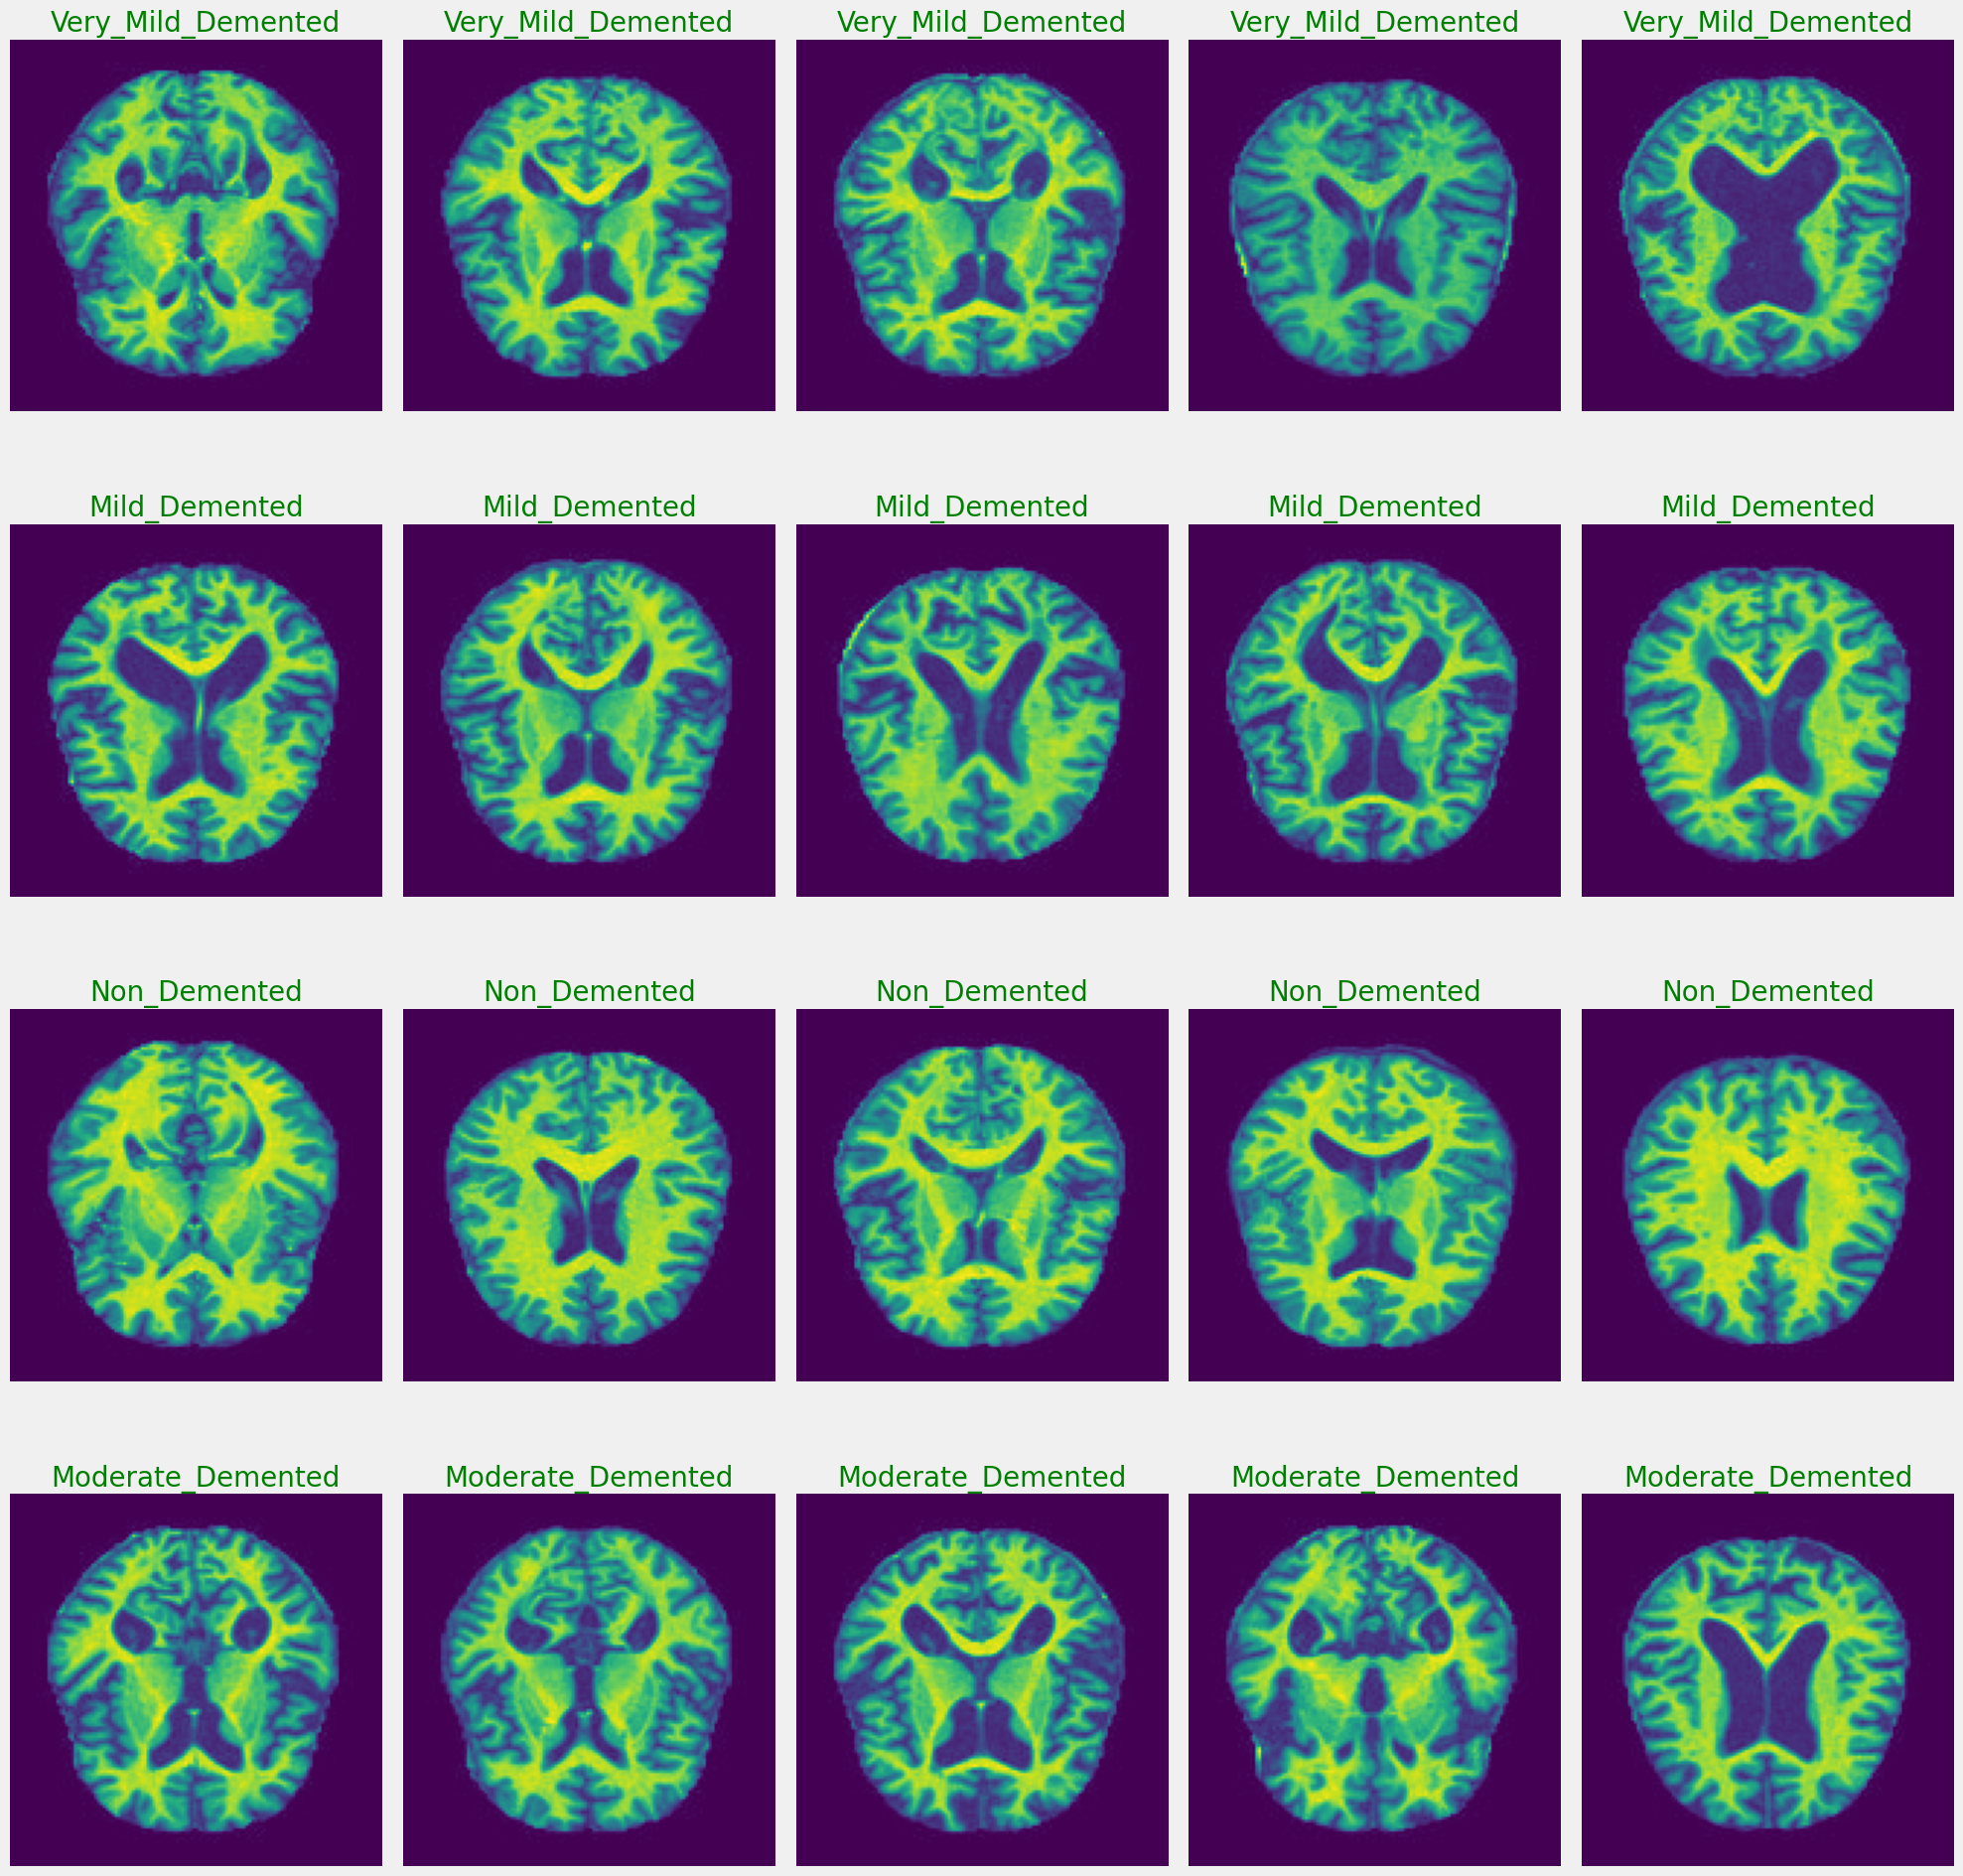

In [9]:
# Visualizing the images for each target variable class

# Making subplots by defining rows and columns
fig, ax = plt.subplots(4, 5, figsize=(20, 20))

# Defining colors for labels 
label_colors = {'Non_Demented': 'green', 
                'Very_Mild_Demented': 'green', 
                'Mild_Demented': 'green', 
                'Moderate_Demented': 'green'}

# Looping through each unique label
for i, label in enumerate(df['label'].unique()):
    
    # Selecting up to 5 images for each label
    images = df[df['label'] == label]['image_path'].head(5)
    
    # Looping through selected images and plotting them
    for j, img_path in enumerate(images):
        
        # applying a condition so each class has five plots
        if j < 5:  
            
            # reading the image using matplotlib
            img = plt.imread(img_path)  
            
            # plotting the image
            ax[i, j].imshow(img)
            
            # setting title for each subplot 
            ax[i, j].set_title(label, color=label_colors[label], fontsize=20)  
            
            # turning axis off
            ax[i, j].axis('off')  
            
# Adjusting layout and display the plot
plt.tight_layout()
plt.show()


- The above figure shows 5 images from each class.

# Data Preparation For Model Building

In [10]:
# converting the categorical labels into numerical ones
df["label"] = df["label"].map({"Non_Demented":0,"Very_Mild_Demented":1,"Mild_Demented":2,"Moderate_Demented":3})

In [11]:
# creating copy of data
data = df.copy()

In [12]:
# splitting data into 80% training and 20% test
train, test = train_test_split(data,test_size=0.2,random_state=21)

In [13]:
# further taking 10% data from training set for validation
train,valid = train_test_split(train,test_size=0.1,random_state=21)


In [14]:
# Function to preprocess image paths into numpy arrays
def preprocess_images(df):
    
    # making a list to store image data
    image_data = []
    
    # list to store labels of images
    labels = []
    
    
    # iterating on dataframe rows
    for index, row in df.iterrows():
        
        # loading the image and resizing it (224,224)
        image = load_img(row['image_path'], target_size=(224, 224))  
        
        # converting the image into a numpy array
        image = img_to_array(image) 
        
        # dividing the image pixels by 255 to normalize them
        image = image / 255.0  
        
        # appending the normalized image to the array
        image_data.append(image)
        
        # appending the image label to the array
        labels.append(row['label'])  
    
    # converting all images into an array
    image_data = np.array(image_data, dtype='float32')
    
    # converting labels list into an array
    labels = np.array(labels)
    
    # Converting labels to one-hot encoding format as we have 4 classes
    labels = to_categorical(labels)
    
    # returning the image array and labels converted to one-hot encoding format
    return image_data, labels




In [15]:
# Preprocessing train, test, and valid dataframes
X_train, y_train = preprocess_images(train)
X_test, y_test = preprocess_images(test)
X_valid, y_valid = preprocess_images(valid)

# VGG16 Model

In [16]:
# Loading VGG16 model (pre-trained on ImageNet, excludeing top layers)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Setting the layers parameters of vgg16 to non trainable
for layer in base_model.layers:
    layer.trainable = False

# Creating a new model
model = Sequential()

# adding the vgg16 to the model
model.add(base_model)

# adding a flattening layer
model.add(Flatten())

# adding the output hidden layer with 4 neurons as we have 4 classes
model.add(Dense(4, activation='softmax'))



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
# Compiling the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [18]:
# showing summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ ?                      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [19]:
# Defining the ModelCheckpoint callback to save the best model based on validation accuracy
checkpoint_first = ModelCheckpoint("first_model.keras", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max', save_weights_only=False)


In [20]:
# Training  the model on training data and validating on validation data
history = model.fit(X_train, y_train,
                    batch_size=32,
                    epochs=30,  
                    validation_data=(X_valid, y_valid),
                   callbacks=[checkpoint_first])


Epoch 1/30


2024-06-23 20:06:27.907775: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 0: 4.63498, expected 3.85968
2024-06-23 20:06:27.907841: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 3: 6.55784, expected 5.78254
2024-06-23 20:06:27.907850: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 4: 6.61282, expected 5.83752
2024-06-23 20:06:27.907858: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 6: 6.34499, expected 5.56968
2024-06-23 20:06:27.907866: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 7: 6.25159, expected 5.47629
2024-06-23 20:06:27.907873: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 8: 5.43964, expected 4.66434
2024-06-23 20:06:27.907881: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 9: 6.54333, expected 5.76803
2024-06-23 20:06:27.907888: E external/local_xla/xla/se

  2/144 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.4375 - loss: 1.3180  

I0000 00:00:1719173203.425457      97 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5542 - loss: 1.1384
Epoch 1: val_accuracy improved from -inf to 0.73047, saving model to first_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 31s 86ms/step - accuracy: 0.5546 - loss: 1.1368 - val_accuracy: 0.7305 - val_loss: 0.6293
Epoch 2/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7574 - loss: 0.5715
Epoch 2: val_accuracy improved from 0.73047 to 0.81836, saving model to first_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.7575 - loss: 0.5715 - val_accuracy: 0.8184 - val_loss: 0.4665
Epoch 3/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8508 - loss: 0.4072
Epoch 3: val_accuracy improved from 0.81836 to 0.86719, saving model to first_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.8508 - loss: 0.4072 - val_accuracy: 0.8672 - val_loss: 0.3850
Epoch 4/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8963 - loss: 0.3213
Epoch 4: val_accuracy improved from 0.8

- We trained the famous VGG16 model on our dataset upto 30 epochs, which is a good number to train a model. The accuracy achieved by VGG16 model on training data is 1 which means 100% and on validation data is 0.97 which means 97%.
- The model seem to do overfitting a little bit but it will become clear after analyzing the performance of model on the testing set.

In [21]:
# storing trainin loss & accuracy and validation loss & accuracy in separate variables
training_loss_vgg16 = history.history["loss"]
validation_loss_vgg16 = history.history["val_loss"]
training_accuracy_vgg16 = history.history["accuracy"]
validation_accuracy_vgg16 = history.history["val_accuracy"]

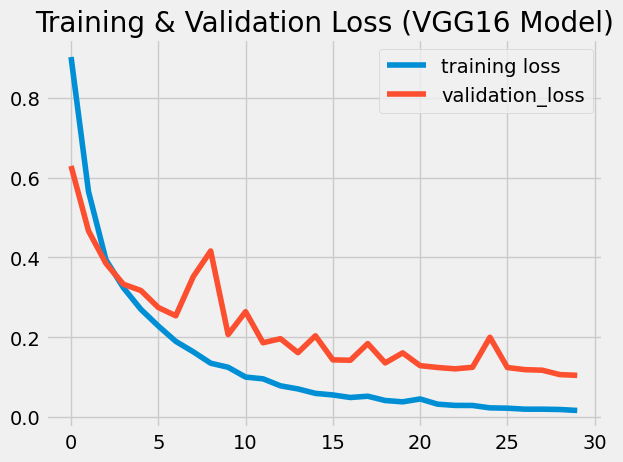

In [23]:
plt.style.use("fivethirtyeight")
plt.plot(training_loss_vgg16,label="training loss")
plt.plot(validation_loss_vgg16,label="validation_loss")
plt.title("Training & Validation Loss (VGG16 Model)")
plt.legend()
plt.show()

- Above figure shows the training and validation loss on taining and validation achieved by the VGG16 model, the training curve is quite smooth but the validation curve has some bumps and it is not smooth as compared to training curve, but it seems to converge and follows the training curve.

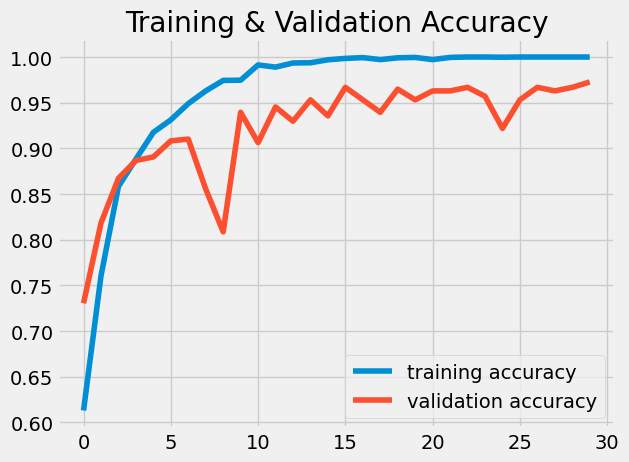

In [24]:
plt.style.use("fivethirtyeight")
plt.plot(training_accuracy_vgg16,label="training accuracy")
plt.plot(validation_accuracy_vgg16,label="validation accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.show()

- The grapgh shows that the VGG16 model achieved the accuracy on training set smoothly but for the validation set the curve is not smooth it has some non smooth curves and it follwos the training accuracy but not smoothly.

In [25]:
# Evaluating the model on test data it's loss and accuracy
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.9635 - loss: 0.1032
Test Loss: 0.1242
Test Accuracy: 0.9586


- The accuracy achieved by the VGG16 model on testing set is 95.86, roughly approximating to 96% which is good but the model has overfitted a little bit as accuracy achieve on training set is 1 or 100%.

In [27]:
# getting predictions from model on testing set
test_probabilities_vgg16 = model.predict(X_test)

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step


In [29]:
# getting predictions from model on testing set
y_predicted_labels_vgg16 = np.argmax(test_probabilities_vgg16,axis=1)
y_actual_labels_vgg16 = np.argmax(y_test,axis=1)


In [31]:
# calculating accuracy of the model on the testing set
vgg16_model_accuracy = metrics.accuracy_score(y_predicted_labels_vgg16,y_actual_labels_vgg16)



In [33]:
# computing confusion matrix of the testing actual labels and prediction by model
cm_vgg16 = metrics.confusion_matrix(y_predicted_labels_vgg16,y_actual_labels_vgg16)

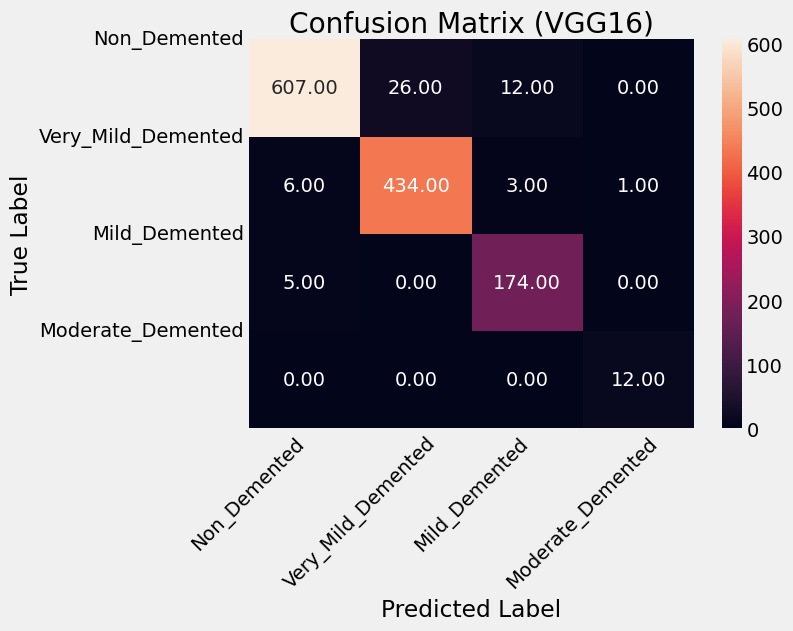

In [35]:
labels = ["Non_Demented", "Very_Mild_Demented", "Mild_Demented", "Moderate_Demented"]

# making heatmap to show confusion matrix
sns.heatmap(cm_vgg16, annot=True, fmt=".2f")

# setting x-tick labels
plt.xticks(ticks=range(len(labels)), labels=labels,rotation=45)
plt.yticks(ticks=range(len(labels)), labels=labels,rotation=360)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (VGG16)')

plt.show()

- The above confusion matrix shows the result of VGG16 model on the testing set. It cleanly classifies all the moderate demented class images making no mistake.
- However, model seem to confuse non demented class with very mild demented class and mild demented class. It misclassified 26 images from non demented class into very mild demented class and misclassified 12 images of non demented class into mild demented class.
- Model is also misclassifying few data points of very mild demented class into non demend (6) and mild demented class (3).
- Model is also misclassifying 5 mild demented class images into non demented class.
- The overall performance of the model is satisfactory as it achieves 96% of accuracy on the testing set.

In [36]:
# computing classification report
cr_vgg16 = metrics.classification_report(y_predicted_labels_vgg16,y_actual_labels_vgg16)
print(cr_vgg16)

              precision    recall  f1-score   support

           0       0.98      0.94      0.96       645
           1       0.94      0.98      0.96       444
           2       0.92      0.97      0.95       179
           3       0.92      1.00      0.96        12

    accuracy                           0.96      1280
   macro avg       0.94      0.97      0.96      1280
weighted avg       0.96      0.96      0.96      1280



# Experimented Architecture
- The following architecture is solely the result of experimentation, we experimented with  alot of architctures and now presenting the best one which gave the best result on testing set.

In [37]:
# Intiating the squential model
model = Sequential()

# adding a convolution layer (350 convolution operations)
model.add(Conv2D(350,kernel_size=(3,3),padding = "same",activation="relu",input_shape=(224,224,3)))

# adding max pooling layer 
model.add(MaxPooling2D(pool_size=(2,2),strides=2,))

# adding a convolution layer (200 convolution operations)
model.add(Conv2D(200,kernel_size=(3,3),padding = "same",activation="relu",))

# adding max pooling layer
model.add(MaxPooling2D(pool_size=(2,2),strides=2,))

# adding a convolution layer (125 convolution operations)
model.add(Conv2D(125,kernel_size=(3,3),padding = "same",activation="relu",))

# adding max pooling layer
model.add(MaxPooling2D(pool_size=(2,2),strides=2,))

# adding a flatten layer 
model.add(Flatten())

# adding a hidden layer with 150 neurons 
model.add(Dense(150,activation="relu"))

#model.add(Dropout(0.1))

# adding a hidden layer with 75 neurons
model.add(Dense(75,activation="relu"))
#model.add(Dropout(0.1))

# adding a hidden layer with 25 neurons
model.add(Dense(25,activation="relu"))

# output layer with 4 neurons as we have 4 classes in target variable
model.add(Dense(4,activation="softmax"))

In [38]:
# Compiling the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [39]:
# Defining the ModelCheckpoint callback to save the best model based on validation accuracy
checkpoint_second = ModelCheckpoint("second_model.keras", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max', save_weights_only=False)


In [40]:
# Training  the model on training data and validating on validation data
history_exp = model.fit(X_train, y_train,
                    batch_size=32,
                    epochs=30,  
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_second]
                   )


Epoch 1/30


2024-06-23 20:15:46.244072: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f32[200,350,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,350,112,112]{3,2,1,0}, f32[32,200,112,112]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0} is taking a while...
2024-06-23 20:15:54.881205: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 9.640419478s
Trying algorithm eng0{} for conv (f32[200,350,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,350,112,112]{3,2,1,0}, f32[32,200,112,112]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0} is taking a while...
2024-06-23 20:15:59.605582: E e

144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.4635 - loss: 1.2343
Epoch 1: val_accuracy improved from -inf to 0.52930, saving model to second_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 79s 187ms/step - accuracy: 0.4638 - loss: 1.2331 - val_accuracy: 0.5293 - val_loss: 0.9362
Epoch 2/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.5901 - loss: 0.8533
Epoch 2: val_accuracy improved from 0.52930 to 0.65625, saving model to second_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 26s 179ms/step - accuracy: 0.5904 - loss: 0.8529 - val_accuracy: 0.6562 - val_loss: 0.7922
Epoch 3/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.7707 - loss: 0.5435
Epoch 3: val_accuracy improved from 0.65625 to 0.81250, saving model to second_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 26s 179ms/step - accuracy: 0.7708 - loss: 0.5432 - val_accuracy: 0.8125 - val_loss: 0.4162
Epoch 4/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.8927 - loss: 0.2828
Epoch 4: val_accuracy improve

- This model has performed better than the VGG16 model, as it shows 100% accuracy on the training set and 98.6% accuracy on the testing set.

In [41]:
training_loss = history_exp.history["loss"]
validation_loss = history_exp.history["val_loss"]
training_accuracy = history_exp.history["accuracy"]
validation_accuracy = history_exp.history["val_accuracy"]

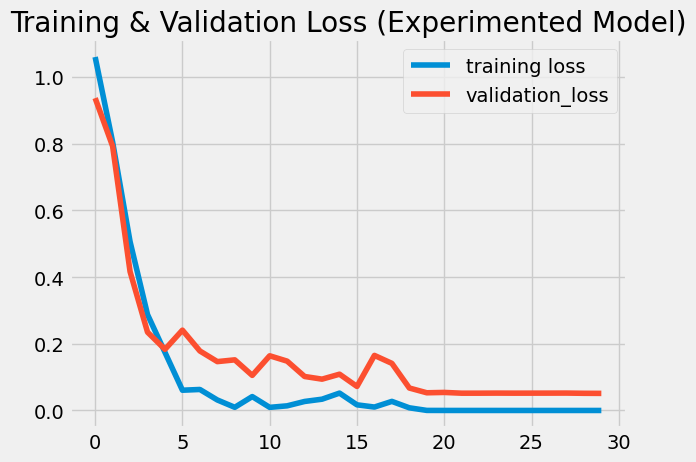

In [42]:
plt.style.use("fivethirtyeight")
plt.plot(training_loss,label="training loss")
plt.plot(validation_loss,label="validation_loss")
plt.title("Training & Validation Loss (Experimented Model)")
plt.legend()
plt.show()

- The grapgh shows that the loss curve for both training and validation set show some bumps in the beginning but seem to converge slowly after around 18 epoch.

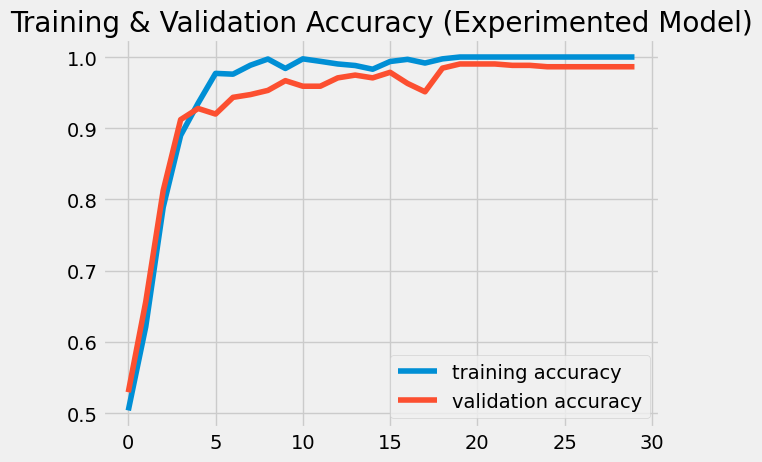

In [43]:
plt.style.use("fivethirtyeight")
plt.plot(training_accuracy,label="training accuracy")
plt.plot(validation_accuracy,label="validation accuracy")
plt.title("Training & Validation Accuracy (Experimented Model)")
plt.legend()
plt.show()

- The grapgh shows the accuracy curves for training and validation set, there are some bumps or non-smoothness int he curves in the beginning but they seem to converge smoothly after around 18 epoch.

In [44]:
# getting prediction on test set by the model architecture 
test_probabilities = model.predict(X_test)

# as we get probabilities in return so getting the index with highest probability
y_predicted_labels = np.argmax(test_probabilities,axis=1)
y_actual_labels = np.argmax(y_test,axis=1)



40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step


In [45]:
# computing the accuracy for the model
exp_model_accuracy = metrics.accuracy_score(y_predicted_labels,y_actual_labels)

In [46]:
# computing confusion matrix for model
cm_exp_model = metrics.confusion_matrix(y_predicted_labels,y_actual_labels)

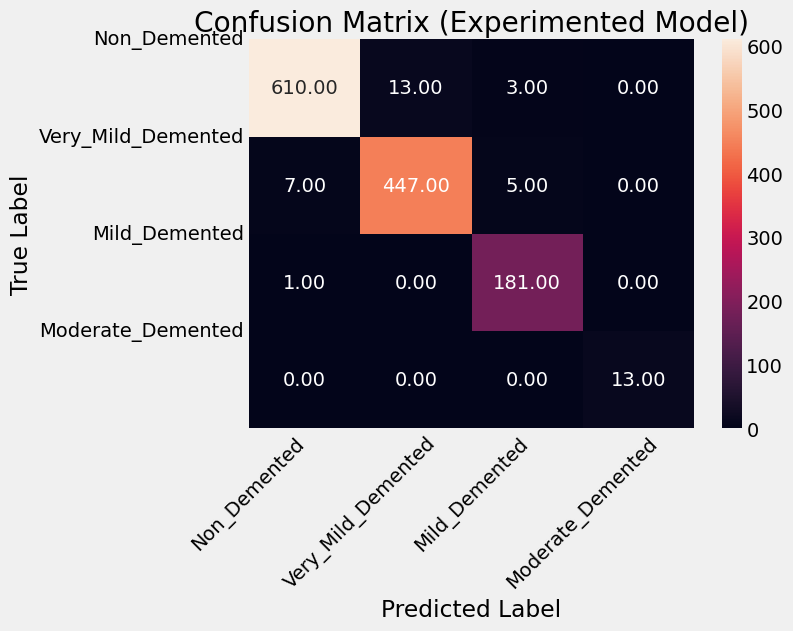

In [47]:
labels = ["Non_Demented", "Very_Mild_Demented", "Mild_Demented", "Moderate_Demented"]

# making heatmap to show confusion matrix
sns.heatmap(cm_exp_model, annot=True, fmt=".2f")

# setting x-tick labels
plt.xticks(ticks=range(len(labels)), labels=labels,rotation=45)
plt.yticks(ticks=range(len(labels)), labels=labels,rotation=360)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Experimented Model)')

plt.show()

- This confusion matrix as compared with the confusion matrix of VGG16 model is better.
- It cleanly classifies all the images correctly for moderated demented class.
- Only few images from non-demented class have been misclassified into very mild demednted (13 images) and mild demented (3 images).
- Very mild demented class 7 images are misclassified into non-demented class and 5 images into mild demented class.
- Only 1 image of mild demented class have been misclassified into non demented class.
- The overall results of this model are extremely good and they outperforms the famous VGG16 architecture results.

In [48]:
# computing classification report
cr = metrics.classification_report(y_predicted_labels,y_actual_labels)
print(cr)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       626
           1       0.97      0.97      0.97       459
           2       0.96      0.99      0.98       182
           3       1.00      1.00      1.00        13

    accuracy                           0.98      1280
   macro avg       0.98      0.99      0.98      1280
weighted avg       0.98      0.98      0.98      1280



In [55]:
exp_model_accuracy

0.97734375

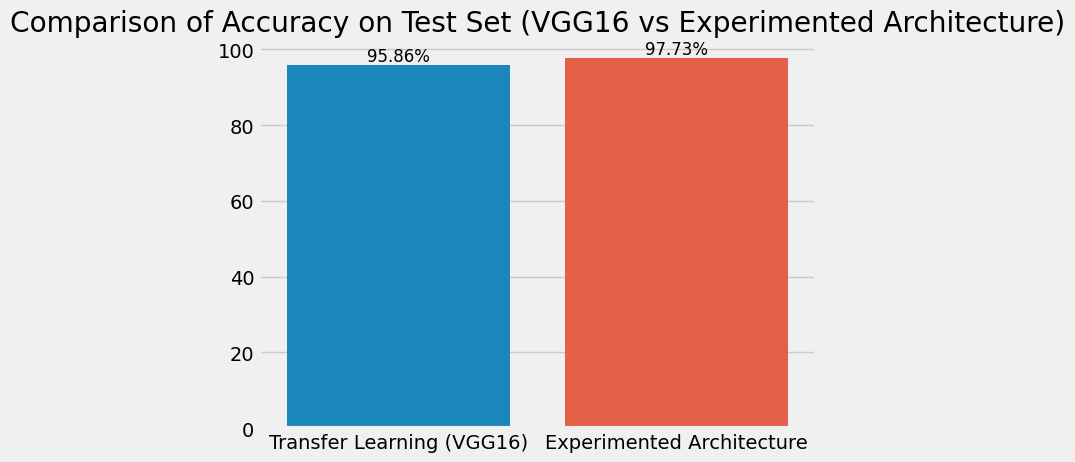

In [62]:
model_labels = ["Transfer Learning (VGG16)", "Experimented Architecture"]
accuracies = [vgg16_model_accuracy * 100, exp_model_accuracy * 100]

# Creating the bar plot
sns.barplot(x=model_labels, y=accuracies)
plt.title("Comparison of Accuracy on Test Set (VGG16 vs Experimented Architecture)")

# Annotating the bars with their respective values formatted to two decimal places
for index, value in enumerate(accuracies):
    plt.text(index, value, f"{value:.2f}%", ha='center', va='bottom', fontsize=12)

plt.show()


- The above bar chart shows the comparison of accuracy achieved by VGG16 model and Experimented architecture on the testing set.
- The experimented architecture is outperforming the VGG16 architecture.
- The experimented architecture shows 97.73% accuracy on testing and VGG16 model shows 95.86% accuracy on the testing set.

# Conclusion
The integration of Artificial Intelligence (AI) into healthcare represents a transformative leap forward, and our Alzheimer's disease classification project exemplifies this evolution. As AI technologies continue to advance, they promise to revolutionize healthcare by offering unprecedented precision in diagnosis, personalized treatment options, and efficient patient management.

This project has demonstrated how AI can enhance the accuracy and speed of Alzheimer's disease diagnosis, ultimately benefiting the healthcare system by enabling earlier and more reliable identification of the condition. Early diagnosis is crucial in managing Alzheimer's disease effectively, as it allows for timely intervention and personalized treatment plans that can significantly improve patient outcomes and quality of life.

Looking ahead, AI is poised to reshape the healthcare landscape in several ways:

- **Enhanced Diagnostic Precision:** AI's ability to analyze vast amounts of medical data with high accuracy will lead to more precise and reliable diagnoses. This will reduce diagnostic errors and ensure that patients receive appropriate treatments based on their specific conditions.

- **Personalized Medicine:** AI will enable the development of tailored treatment plans by analyzing individual patient data and predicting how they will respond to different therapies. This personalized approach will optimize treatment efficacy and minimize adverse effects.

- **Predictive Analytics:** AI-powered predictive analytics will facilitate the early detection of diseases and potential health risks, allowing for proactive management and preventive measures. This shift from reactive to proactive care will improve patient outcomes and reduce healthcare costs.

- **Operational Efficiency:** AI will streamline administrative processes, enhance resource allocation, and improve patient management within healthcare systems. By automating routine tasks and analyzing operational data, AI will enable healthcare providers to focus more on patient care and less on administrative burdens.

- **Research and Development:** AI will accelerate research efforts by analyzing complex datasets, identifying new patterns, and generating insights that may lead to breakthroughs in treatment and drug development.

In conclusion, this Alzheimer's disease classification project underscores the potential of AI to revolutionize healthcare. By leveraging AI's capabilities, we can advance diagnostic accuracy, personalize treatments, and enhance overall healthcare efficiency. The ongoing evolution of AI technology will undoubtedly continue to drive significant improvements in patient care and transform the healthcare system for the better.